In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
# torch.manual_seed(RANDOM_SEED)

# --- 1. 读取数据 ---
case_info_df = pd.read_csv('data/case_info.csv')[['id', 'blast', 'bili_height', 'height']]
data_folder = 'data/collect_pressure_peak'

# --- 2. 按算例文件读取数据，保存每个case的原始信息 ---
all_case_data = []  # 存储每个case的数据
case_files_list = []  # 存储case文件名

for filename in os.listdir(data_folder):
    case_path = os.path.join(data_folder, filename)
    case_row = case_info_df[case_info_df['id'] == filename]
    if case_row.empty: 
        continue
    
    blast, b_height, height = case_row.iloc[0]['blast'], case_row.iloc[0]['bili_height'], case_row.iloc[0]['height']
    
    try:
        points_data = np.loadtxt(case_path)
    except:
        continue
    
    case_X = []
    case_y = []
    
    for row in points_data:
        x, y, z, p = row[0], row[1], row[2], row[3] - 101325
        R = np.sqrt(x**2 + y**2 + z**2)
        Z = R / (blast**(1/3)) if blast > 0 else R
        case_X.append([x, y, z, blast, b_height, height, R, Z])
        case_y.append(p)
    
    if len(case_X) > 0:
        all_case_data.append({
            'case_file': filename,
            'X': np.array(case_X),
            'y': np.array(case_y).reshape(-1, 1)
        })
        case_files_list.append(filename)

print(f"总共加载 {len(all_case_data)} 个算例文件")

# --- 3. 按算例文件划分训练集和测试集 ---
n_total_files = len(all_case_data)
n_test_files = int(n_total_files * 0.2)  # 20% 的文件作为测试集
if n_test_files < 1:
    n_test_files = 1

# 随机打乱文件顺序
np.random.seed(RANDOM_SEED)
shuffled_indices = np.random.permutation(n_total_files)
test_indices = shuffled_indices[:n_test_files]
train_indices = shuffled_indices[n_test_files:]

# 划分数据
train_cases = [all_case_data[i] for i in train_indices]
test_cases = [all_case_data[i] for i in test_indices]

print(f"训练算例数: {len(train_cases)}, 测试算例数: {len(test_cases)}")

# 合并训练集和测试集的特征和标签
X_train_list = [case['X'] for case in train_cases]
y_train_list = [case['y'] for case in train_cases]
X_test_list = [case['X'] for case in test_cases]
y_test_list = [case['y'] for case in test_cases]

X_train = np.vstack(X_train_list)
y_train = np.vstack(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)

print(f"训练集样本数: {len(X_train)}, 测试集样本数: {len(X_test)}")

# --- 4. 特征标准化（只在训练集上拟合）---
scaler_X = StandardScaler()
X_train_norm = scaler_X.fit_transform(X_train)
X_test_norm = scaler_X.transform(X_test)

# 保存标准化器
joblib.dump(scaler_X, 'scaler_X.pkl')

# --- 5. 标签缩放（线性缩放，不用对数）---
Y_SCALE_FACTOR = 1000000.0  # 1e6 为1个单位
y_train_scaled = y_train / Y_SCALE_FACTOR
y_test_scaled = y_test / Y_SCALE_FACTOR

# --- 6. 创建DataLoader ---
train_dataset = TensorDataset(
    torch.tensor(X_train_norm, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_norm, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# --- 7. 定义模型 ---
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()  # 保证输出压力为正数
        )
    
    def forward(self, x):
        return self.net(x)

model = ImprovedMLP(input_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- 8. MAPE Loss ---
def mape_loss(pred, true):
    return torch.mean(torch.abs((pred - true) / (true + 1e-5)))

# --- 9. 训练模型 ---
epochs = 100
best_val_loss = float('inf')

print("\n开始训练...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = mape_loss(pred, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # 验证
    if (epoch + 1) % 20 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                val_loss += mape_loss(model(batch_X), batch_y).item()
        val_loss /= len(test_loader)
        
        print(f"Epoch {epoch+1:3d} | Train MAPE: {train_loss*100:6.2f}% | Val MAPE: {val_loss*100:6.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_mlp_mape.pth')
            print(f"  -> 保存最佳模型 (Val MAPE: {val_loss*100:.2f}%)")

# --- 10. 加载最佳模型进行评估 ---
print("\n加载最佳模型进行评估...")
model.load_state_dict(torch.load('best_mlp_mape.pth'))
model.eval()

# 测试集总体评估
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test_norm, dtype=torch.float32)).numpy()
    y_pred = y_pred_scaled * Y_SCALE_FACTOR
    y_true = y_test

# 计算指标
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

print(f"\n===== 测试集总体指标 =====")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f} Pa")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# --- 11. 输出测试集包含的算例文件 ---
print(f"\n===== 测试集包含的算例文件（共 {len(test_cases)} 个）=====")
for case in test_cases:
    print(f"  {case['case_file']}")

# --- 12. 按文件分组评估 ---
print(f"\n===== 每个文件的回归指标 =====")
print(f"{'文件名':<20s} {'样本数':<8s} {'MAE(Pa)':<12s} {'MAPE(%)':<12s} {'R²':<12s}")

for case in test_cases:
    case_name = case['case_file']
    y_true_file = case['y']
    
    # 预测该case的数据
    X_case_norm = scaler_X.transform(case['X'])
    with torch.no_grad():
        y_pred_scaled_file = model(torch.tensor(X_case_norm, dtype=torch.float32)).numpy()
        y_pred_file = y_pred_scaled_file * Y_SCALE_FACTOR
    
    n = len(y_true_file)
    mae_file = mean_absolute_error(y_true_file, y_pred_file)
    mape_file = np.mean(np.abs((y_true_file - y_pred_file) / (y_true_file + 1e-10))) * 100
    
    if n >= 2:
        r2_file = r2_score(y_true_file, y_pred_file)
    else:
        r2_file = float('nan')
    
    print(f"{case_name:<20s} {n:<8d} {mae_file:<12.2f} {mape_file:<12.2f} {r2_file:<12.4f}")

# --- 13. 测试特定点 ---
print("\n--- 测试特定点 ---")
test_points = [
    {"x": 0.0, "y": 0.0, "z": 0.0, "blast": 0.1, "b_height": 30.0, "height": 13.92, "true_val": 1886690.00},
    {"x": 70.7107, "y": 70.7107, "z": 0.0, "blast": 0.1, "b_height": 30.0, "height": 13.92, "true_val": 144310.00},
    {"x": 141.421, "y": 141.421, "z": 0.0, "blast": 0.1, "b_height": 30.0, "height": 13.92, "true_val": 114141.00},
    {"x": 212.132, "y": 212.132, "z": 0.0, "blast": 0.1, "b_height": 30.0, "height": 13.92, "true_val": 106602.00},
]

for p in test_points:
    x, y, z, blast, b_height, height = p['x'], p['y'], p['z'], p['blast'], p['b_height'], p['height']
    R = np.sqrt(x**2 + y**2 + z**2)
    Z = R / (blast**(1/3)) if blast > 0 else R
    
    new_input = np.array([[x, y, z, blast, b_height, height, R, Z]])
    norm_new_input = scaler_X.transform(new_input)
    
    with torch.no_grad():
        tensor_new_input = torch.tensor(norm_new_input, dtype=torch.float32)
        new_pred_real = (model(tensor_new_input).numpy() * Y_SCALE_FACTOR)[0][0]
    
    error = abs(new_pred_real - p['true_val']) / p['true_val'] * 100
    print(f"坐标: [{x:>6}, {y:>6}, {z:>6}], 真值: {p['true_val']:>10.2f}, 预测: {new_pred_real:>10.2f}, 误差: {error:>5.2f}%")

print("\n训练完成！")

/opt/conda/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


总共加载 39 个算例文件
训练算例数: 32, 测试算例数: 7
训练集样本数: 9442, 测试集样本数: 2107

开始训练...
Epoch  20 | Train MAPE:  16.59% | Val MAPE:  16.90%
  -> 保存最佳模型 (Val MAPE: 16.90%)
Epoch  40 | Train MAPE:  14.91% | Val MAPE:  19.16%
Epoch  60 | Train MAPE:  14.30% | Val MAPE:  19.22%
Epoch  80 | Train MAPE:  14.24% | Val MAPE:  21.36%
Epoch 100 | Train MAPE:  13.33% | Val MAPE:  21.31%

加载最佳模型进行评估...

===== 测试集总体指标 =====
MSE: 6455353668.67
MAE: 12806.00 Pa
MAPE: 16.94%
R²: 0.6280

===== 测试集包含的算例文件（共 7 个）=====
  value23
  value14
  value35
  value18
  value38
  value12
  value24

===== 每个文件的回归指标 =====
文件名                  样本数      MAE(Pa)      MAPE(%)      R²          
value23              301      10934.38     18.60        0.9300      
value14              301      1835.43      30.56        0.9871      
value35              301      16623.70     18.59        0.9014      
value18              301      10586.48     14.00        0.8612      
value38              301      19015.56     14.78        0.8407      
value1

正在读取数据...
总共加载 39 个算例文件
训练算例数: 32, 测试算例数: 7
测试集样本数: 2107

正在加载标准化器和模型...
模型加载成功！

正在进行预测...

===== 测试集总体指标 =====
RMSE: 80.35kPa
MAE: 12.81kPa
MAPE: 16.94%
R²: 0.6280

散点图已保存至: prediction_scatter_plot.png


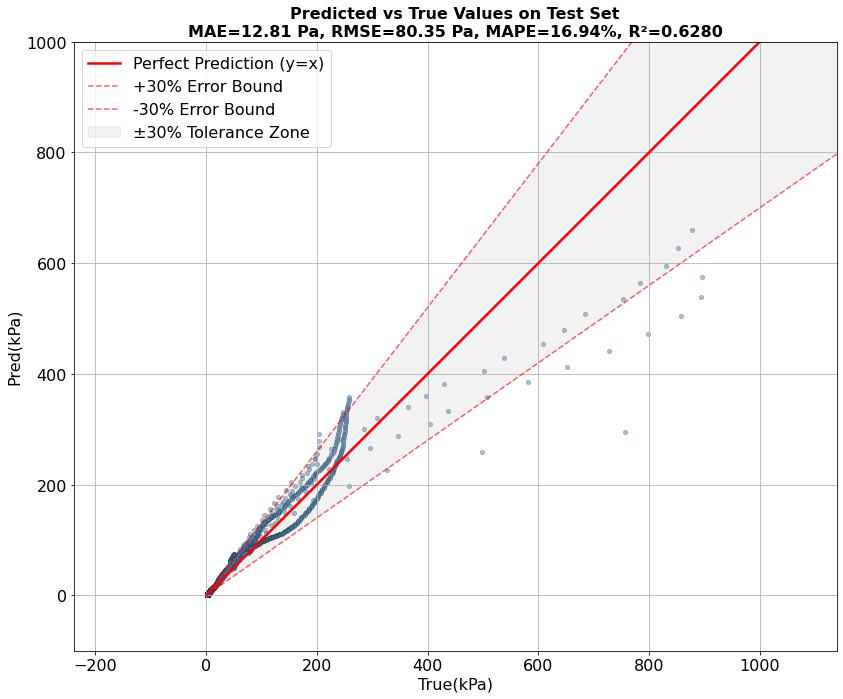


===== 测试集包含的算例文件（共 7 个）=====
  value23
  value14
  value35
  value18
  value38
  value12
  value24

===== 每个文件的回归指标 =====
文件名                            样本数      MAE(Pa)      MAPE(%)      R²          
--------------------------------------------------------------------------------
value23                        301      10934.38     18.60        0.9300      
value14                        301      1835.43      30.56        0.9871      
value35                        301      16623.70     18.59        0.9014      
value18                        301      10586.48     14.00        0.8612      
value38                        301      19015.56     14.78        0.8407      
value12                        301      25399.40     11.62        0.3522      
value24                        301      5247.05      10.44        0.9048      

===== 误差统计 =====
落在±30%误差范围内的点比例: 85.24%

预测和可视化完成！


In [18]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ====================== 配置路径 ======================
CASE_INFO_PATH = "data/case_info.csv"
DATA_FOLDER = "data/collect_pressure_peak"
MODEL_PATH = "best_mlp_mape.pth"
SCALER_PATH = "scaler_X.pkl"
Y_SCALE_FACTOR = 1000000.0  # 必须与训练时一致

# ====================== 定义模型结构（必须与训练时一致）======================
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()  # 保证输出压力为正数
        )
    
    def forward(self, x):
        return self.net(x)

# ====================== 1. 读取数据 ======================
print("正在读取数据...")
case_info_df = pd.read_csv(CASE_INFO_PATH)[['id', 'blast', 'bili_height', 'height']]

# 按算例文件读取数据
all_case_data = []
case_files_list = []

for filename in os.listdir(DATA_FOLDER):
    case_path = os.path.join(DATA_FOLDER, filename)
    case_row = case_info_df[case_info_df['id'] == filename]
    if case_row.empty: 
        continue
    
    blast, b_height, height = case_row.iloc[0]['blast'], case_row.iloc[0]['bili_height'], case_row.iloc[0]['height']
    
    try:
        points_data = np.loadtxt(case_path)
    except:
        continue
    
    case_X = []
    case_y = []
    
    for row in points_data:
        x, y, z, p = row[0], row[1], row[2], row[3] - 101325
        R = np.sqrt(x**2 + y**2 + z**2)
        Z = R / (blast**(1/3)) if blast > 0 else R
        case_X.append([x, y, z, blast, b_height, height, R, Z])
        case_y.append(p)
    
    if len(case_X) > 0:
        all_case_data.append({
            'case_file': filename,
            'X': np.array(case_X),
            'y': np.array(case_y).reshape(-1, 1)
        })
        case_files_list.append(filename)

print(f"总共加载 {len(all_case_data)} 个算例文件")

# ====================== 2. 按算例文件划分数据集（使用相同的随机种子）======================
n_total_files = len(all_case_data)
n_test_files = int(n_total_files * 0.2)
if n_test_files < 1:
    n_test_files = 1

np.random.seed(RANDOM_SEED)
shuffled_indices = np.random.permutation(n_total_files)
test_indices = shuffled_indices[:n_test_files]
train_indices = shuffled_indices[n_test_files:]

train_cases = [all_case_data[i] for i in train_indices]
test_cases = [all_case_data[i] for i in test_indices]

print(f"训练算例数: {len(train_cases)}, 测试算例数: {len(test_cases)}")

# 合并测试集数据
X_test_list = [case['X'] for case in test_cases]
y_test_list = [case['y'] for case in test_cases]

X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)

print(f"测试集样本数: {len(X_test)}")

# ====================== 3. 加载标准化器和模型 ======================
print("\n正在加载标准化器和模型...")
scaler_X = joblib.load(SCALER_PATH)
X_test_norm = scaler_X.transform(X_test)

# 加载模型
model = ImprovedMLP(input_dim=8)
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()
print("模型加载成功！")

# ====================== 4. 进行预测 ======================
print("\n正在进行预测...")
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test_norm, dtype=torch.float32)).numpy()
    y_pred = y_pred_scaled * Y_SCALE_FACTOR/1000
    y_true = y_test/1000

# ====================== 5. 计算评估指标 ======================
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

print(f"\n===== 测试集总体指标 =====")
print(f"RMSE: {rmse:.2f}kPa")
print(f"MAE: {mae:.2f}kPa")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# ====================== 6. 绘制散点图 ======================
plt.figure(figsize=(12, 10))

# 设置全局字体
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16

# 散点图
plt.scatter(y_true, y_pred, alpha=0.5, s=20, c='steelblue', edgecolors='k', linewidth=0.3)

# 完美预测线
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r', linewidth=2.5, label='Perfect Prediction (y=x)')

# ±30% 误差线
x_line = np.linspace(min_val, max_val, 100)
plt.plot(x_line, x_line * 1.3, 'r--', alpha=0.6, linewidth=1.5, label='+30% Error Bound')
plt.plot(x_line, x_line * 0.7, 'r--', alpha=0.6, linewidth=1.5, label='-30% Error Bound')

# 填充±30%区域
plt.fill_between(x_line, x_line * 0.7, x_line * 1.3, alpha=0.1, color='gray', label='±30% Tolerance Zone')

# 设置坐标轴
plt.xlabel('True(kPa)', fontsize=16)
plt.ylabel('Pred(kPa)', fontsize=16)
plt.title(f'Predicted vs True Values on Test Set\n'
          f'MAE={mae:.2f} Pa, RMSE={rmse:.2f} Pa, MAPE={mape:.2f}%, R²={r2:.4f}',
          fontweight='bold', fontsize=16)

plt.legend(loc='best', fontsize=16)
plt.grid()
plt.axis('equal')
plt.tight_layout()
plt.xlim([-100,1000])
plt.ylim([-100,1000])
# 保存图片
plt.savefig('prediction_scatter_plot.png', dpi=300, bbox_inches='tight')
print("\n散点图已保存至: prediction_scatter_plot.png")
plt.show()

# ====================== 8. 输出测试集包含的算例文件 ======================
print(f"\n===== 测试集包含的算例文件（共 {len(test_cases)} 个）=====")
for case in test_cases:
    print(f"  {case['case_file']}")

# ====================== 9. 按文件分组评估 ======================
print(f"\n===== 每个文件的回归指标 =====")
print(f"{'文件名':<30s} {'样本数':<8s} {'MAE(Pa)':<12s} {'MAPE(%)':<12s} {'R²':<12s}")
print("-" * 80)

for case in test_cases:
    case_name = case['case_file']
    y_true_file = case['y']
    
    X_case_norm = scaler_X.transform(case['X'])
    with torch.no_grad():
        y_pred_scaled_file = model(torch.tensor(X_case_norm, dtype=torch.float32)).numpy()
        y_pred_file = y_pred_scaled_file * Y_SCALE_FACTOR
    
    n = len(y_true_file)
    mae_file = mean_absolute_error(y_true_file, y_pred_file)
    mape_file = np.mean(np.abs((y_true_file - y_pred_file) / (y_true_file + 1e-10))) * 100
    
    if n >= 2:
        r2_file = r2_score(y_true_file, y_pred_file)
    else:
        r2_file = float('nan')
    
    print(f"{case_name:<30s} {n:<8d} {mae_file:<12.2f} {mape_file:<12.2f} {r2_file:<12.4f}")

# ====================== 10. 统计落在±30%内的点比例 ======================
within_30 = np.abs((y_true - y_pred) / (y_true + 1e-10)) <= 0.30
percent_within = np.mean(within_30) * 100
print(f"\n===== 误差统计 =====")
print(f"落在±30%误差范围内的点比例: {percent_within:.2f}%")

print("\n预测和可视化完成！")

正在读取数据...
总共加载 39 个算例文件
训练算例数: 32, 测试算例数: 7
测试集文件: ['value23', 'value14', 'value35', 'value18', 'value38', 'value12', 'value24']

正在加载标准化器和模型...
模型加载成功！

正在绘制算例: value23
该算例样本数: 301
坐标范围: X=[0.0, 4242.6], Y=[0.0, 4242.6]
预测完成，预测值形状: (301,), 真实值形状: (301,)

===== 算例 value23 评估指标 =====
MAE: 10934.38 Pa
RMSE: 36045.70 Pa
MAPE: 18.60%
R²: 0.9300

图片已保存至: value23_2d_comparison.png


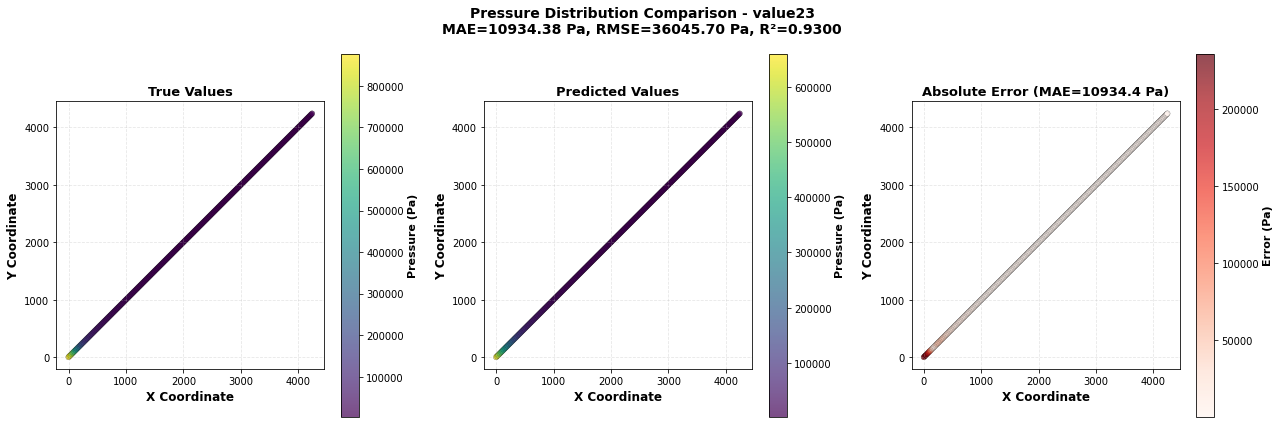


===== 算例详细信息 =====
文件名: value23
爆炸参数: blast=10.0, height=215.44, bili_height=100
测点数量: 301
压力范围: 真实值 [3502, 876996] Pa
压力范围: 预测值 [2486, 659581] Pa
误差范围: [6, 235885] Pa
压力-距离图已保存至: value23_pressure_vs_distance.png


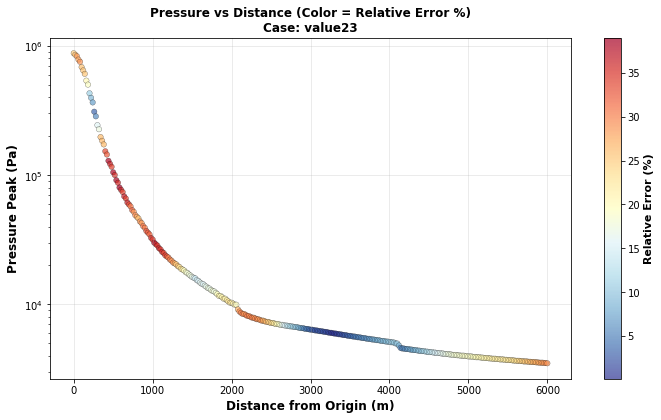


所有绘图完成！


In [22]:
import os
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ====================== 路径配置 ======================
CASE_INFO_PATH = "data/case_info.csv"
DATA_FOLDER = "data/collect_pressure_peak"
MODEL_PATH = "best_mlp_mape.pth"
SCALER_PATH = "scaler_X.pkl"
Y_SCALE_FACTOR = 1000000.0

# ====================== 定义模型结构 ======================
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()
        )
    
    def forward(self, x):
        return self.net(x)

# ====================== 1. 读取数据 ======================
print("正在读取数据...")
case_info_df = pd.read_csv(CASE_INFO_PATH)[['id', 'blast', 'bili_height', 'height']]

# 按算例文件读取数据
all_case_data = []
case_files_list = []

for filename in os.listdir(DATA_FOLDER):
    case_path = os.path.join(DATA_FOLDER, filename)
    case_row = case_info_df[case_info_df['id'] == filename]
    if case_row.empty: 
        continue
    
    blast, b_height, height = case_row.iloc[0]['blast'], case_row.iloc[0]['bili_height'], case_row.iloc[0]['height']
    
    try:
        points_data = np.loadtxt(case_path)
    except:
        continue
    
    case_X = []
    case_y = []
    
    for row in points_data:
        x, y, z, p = row[0], row[1], row[2], row[3] - 101325
        R = np.sqrt(x**2 + y**2 + z**2)
        Z = R / (blast**(1/3)) if blast > 0 else R
        case_X.append([x, y, z, blast, b_height, height, R, Z])
        case_y.append(p)
    
    if len(case_X) > 0:
        all_case_data.append({
            'case_file': filename,
            'X': np.array(case_X),
            'y': np.array(case_y).reshape(-1, 1),
            'points_data': points_data,  # 保存原始数据
            'x_coords': points_data[:, 0],
            'y_coords': points_data[:, 1],
            'z_coords': points_data[:, 2]
        })
        case_files_list.append(filename)

print(f"总共加载 {len(all_case_data)} 个算例文件")

# ====================== 2. 按算例文件划分数据集 ======================
n_total_files = len(all_case_data)
n_test_files = int(n_total_files * 0.2)
if n_test_files < 1:
    n_test_files = 1

np.random.seed(RANDOM_SEED)
shuffled_indices = np.random.permutation(n_total_files)
test_indices = shuffled_indices[:n_test_files]
train_indices = shuffled_indices[n_test_files:]

train_cases = [all_case_data[i] for i in train_indices]
test_cases = [all_case_data[i] for i in test_indices]

print(f"训练算例数: {len(train_cases)}, 测试算例数: {len(test_cases)}")
print(f"测试集文件: {[case['case_file'] for case in test_cases]}")

# ====================== 3. 加载标准化器和模型 ======================
print("\n正在加载标准化器和模型...")
scaler_X = joblib.load(SCALER_PATH)

model = ImprovedMLP(input_dim=8)
model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device('cpu')))
model.eval()
print("模型加载成功！")

# ====================== 4. 选择要绘制的算例 ======================
selected_case = test_cases[0]
case_name = selected_case['case_file']

# 直接使用保存的坐标，确保维度一致
x_coords = selected_case['x_coords']
y_coords = selected_case['y_coords']
z_coords = selected_case['z_coords']
y_true = selected_case['points_data'][:, 3] - 101325

print(f"\n正在绘制算例: {case_name}")
print(f"该算例样本数: {len(x_coords)}")
print(f"坐标范围: X=[{x_coords.min():.1f}, {x_coords.max():.1f}], Y=[{y_coords.min():.1f}, {y_coords.max():.1f}]")

# 获取该算例的参数
case_row = case_info_df[case_info_df['id'] == case_name].iloc[0]
blast, b_height, height = case_row['blast'], case_row['bili_height'], case_row['height']

# 预测所有点
X_case = selected_case['X']  # 直接使用已保存的特征

X_case_norm = scaler_X.transform(X_case)

with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_case_norm, dtype=torch.float32)).numpy()
    y_pred = y_pred_scaled * Y_SCALE_FACTOR

# 确保维度一致
y_pred = y_pred.flatten()
y_true = y_true.flatten()

print(f"预测完成，预测值形状: {y_pred.shape}, 真实值形状: {y_true.shape}")

# 计算误差
absolute_error = np.abs(y_pred - y_true)
mae = np.mean(absolute_error)
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
mape = np.mean(np.abs((y_pred - y_true) / (y_true + 1e-10))) * 100
r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print(f"\n===== 算例 {case_name} 评估指标 =====")
print(f"MAE: {mae:.2f} Pa")
print(f"RMSE: {rmse:.2f} Pa")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

# ====================== 5. 绘制三个图 ======================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# 图1: 真实值分布
scatter1 = axes[0].scatter(x_coords, y_coords, c=y_true, 
                           cmap='viridis', s=30, alpha=0.7, 
                           edgecolors='k', linewidth=0.3)
axes[0].set_title(f'True Values', fontweight='bold', fontsize=13)
axes[0].set_xlabel('X Coordinate', fontweight='bold')
axes[0].set_ylabel('Y Coordinate', fontweight='bold')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3, linestyle='--')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Pressure (Pa)', fontsize=11, fontweight='bold')

# 图2: 预测值分布
scatter2 = axes[1].scatter(x_coords, y_coords, c=y_pred, 
                           cmap='viridis', s=30, alpha=0.7, 
                           edgecolors='k', linewidth=0.3)
axes[1].set_title(f'Predicted Values', fontweight='bold', fontsize=13)
axes[1].set_xlabel('X Coordinate', fontweight='bold')
axes[1].set_ylabel('Y Coordinate', fontweight='bold')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3, linestyle='--')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Pressure (Pa)', fontsize=11, fontweight='bold')

# 图3: 绝对误差分布
scatter3 = axes[2].scatter(x_coords, y_coords, c=absolute_error, 
                           cmap='Reds', s=30, alpha=0.7, 
                           edgecolors='k', linewidth=0.3)
axes[2].set_title(f'Absolute Error (MAE={mae:.1f} Pa)', fontweight='bold', fontsize=13)
axes[2].set_xlabel('X Coordinate', fontweight='bold')
axes[2].set_ylabel('Y Coordinate', fontweight='bold')
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3, linestyle='--')
cbar3 = plt.colorbar(scatter3, ax=axes[2])
cbar3.set_label('Error (Pa)', fontsize=11, fontweight='bold')

plt.suptitle(f'Pressure Distribution Comparison - {case_name}\n'
              f'MAE={mae:.2f} Pa, RMSE={rmse:.2f} Pa, R²={r2:.4f}',
              fontsize=14, fontweight='bold')

plt.tight_layout()

save_path = f'{case_name}_2d_comparison.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"\n图片已保存至: {save_path}")
plt.show()

# ====================== 6. 打印该算例的详细信息 ======================
print(f"\n===== 算例详细信息 =====")
print(f"文件名: {case_name}")
print(f"爆炸参数: blast={blast}, height={height}, bili_height={b_height}")
print(f"测点数量: {len(x_coords)}")
print(f"压力范围: 真实值 [{y_true.min():.0f}, {y_true.max():.0f}] Pa")
print(f"压力范围: 预测值 [{y_pred.min():.0f}, {y_pred.max():.0f}] Pa")
print(f"误差范围: [{absolute_error.min():.0f}, {absolute_error.max():.0f}] Pa")

# ====================== 7. 可选：绘制预测误差随距离的变化 ======================
fig2, ax = plt.subplots(figsize=(10, 6))

# 计算到原点的距离
distances = np.sqrt(x_coords**2 + y_coords**2 + z_coords**2)
relative_errors = absolute_error / (y_true + 1e-10) * 100

scatter = ax.scatter(distances, y_true, c=relative_errors, 
                     cmap='RdYlBu_r', s=30, alpha=0.7, 
                     edgecolors='k', linewidth=0.3)
ax.set_xlabel('Distance from Origin (m)', fontweight='bold', fontsize=12)
ax.set_ylabel('Pressure Peak (Pa)', fontweight='bold', fontsize=12)
ax.set_title(f'Pressure vs Distance (Color = Relative Error %)\nCase: {case_name}',
             fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Relative Error (%)', fontsize=11, fontweight='bold')
ax.set_yscale('log')  # 对数坐标更清晰

plt.tight_layout()
save_path2 = f'{case_name}_pressure_vs_distance.png'
plt.savefig(save_path2, dpi=300, bbox_inches='tight')
print(f"压力-距离图已保存至: {save_path2}")
plt.show()

print("\n所有绘图完成！")